In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm, utils, theory, pickle, os, torch, torchvision
from numpy.linalg import inv as inv

%load_ext autoreload
%autoreload 2


P = 1000
P_test = 500
n_tasks = 2
N0 = 1000
N_teacher = 1000
T = 0
sigma = 0.2
depth = 1

NUM_SEEDS = 20
fixed_w = True
lambda_val=1e7
input_rotation = 0
input_dist = 0

device = torch.device('cpu')

title_text = f'P={P},N0={N0},sigma={sigma},n_tasks={n_tasks},distance={input_dist:.3f}, \n ' +\
          f'lambda={lambda_val},NUM_SEEDS={NUM_SEEDS},input rotation={input_rotation:.3f} \n' +\
    f'depth:{depth},fixed W:{str(fixed_w)},N_teacher:{N_teacher}'

plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 6})

teacher_speeds = np.linspace(0, 1, 10)

test_loss_all_tasks = np.zeros((len(teacher_speeds), NUM_SEEDS, n_tasks, n_tasks))  # only computes the test loss for each distribution AFTER all tasks are learnt
training_loss_all_tasks = np.zeros((len(teacher_speeds), NUM_SEEDS, n_tasks, n_tasks))  # lambda_index, seed_index, time_index, time_index


# measure the test error ON THE LAST TASK from some special schemes
seed_avg_batch_test = np.zeros((len(teacher_speeds), NUM_SEEDS))
seed_avg_last_task_only_test = np.zeros((len(teacher_speeds), NUM_SEEDS))


for sweep_ind in tqdm.trange(len(teacher_speeds)):
    def prepare_student_teacher_data():
        # train_x, test_x = utils.generate_rotating_inputs(P, P_test, N0, n_tasks, rotation=teacher_speeds[sweep_ind], distance=np.sqrt(N0))
        # train_Y, test_Y = utils.get_mix_up_labels(train_x, test_x, max_scaler=teacher_speeds[sweep_ind], teacher_feature_dim=N_teacher)
        train_x, test_x = utils.generate_subspace_inputs(P, P_test, N0, n_tasks, int(N0 / 2), teacher_speeds[sweep_ind])
        train_Y, test_Y = utils.get_teacher_labels(train_x, test_x, max_scaler=1)
        # train_Y, test_Y = utils.get_linear_teacher_labels(train_x, test_x, max_scaler=1)
        return train_x, test_x, train_Y, test_Y


    for seed in range(NUM_SEEDS):
        torch.manual_seed(seed)
        train_x, test_x, train_Y, test_Y = prepare_student_teacher_data()
        # train_x = torch.from_numpy(train_x).float().to(device)
        # test_x = torch.from_numpy(test_x).float().to(device)
        # train_Y = torch.from_numpy(train_Y).float().to(device)
        # test_Y = torch.from_numpy(test_Y).float().to(device)
        train_x = train_x.to(device)
        test_x = test_x.to(device)
        train_Y = train_Y.to(device)

        test_Y = test_Y.to(device)
        #
        # seed_avg_batch_test[seed] = theory.one_task_loss(train_x=np.vstack(train_x), test_x=test_x[-1],
        #                                                  train_y=np.vstack(train_Y), test_y=test_Y[-1], depth=depth)
        # seed_avg_last_task_only_test[seed] = theory.one_task_loss(train_x=train_x[-1], test_x=test_x[-1],
        #                                                           train_y=train_Y[-1], test_y=test_Y[-1], depth=depth)


        training_predictions, test_predictions =\
            theory.compute_mean_predictions(seq_of_train_x=train_x, seq_of_train_y=train_Y, w_var=sigma**2, P_test=P_test,
                                            lambda_val=lambda_val, seq_of_test_x=test_x, fix_weights=fixed_w, disable_tqdm=True, depth=depth)

        test_loss_all_tasks[sweep_ind, seed] = utils.get_loss_matrix_single_task(test_predictions, test_Y)
        training_loss_all_tasks[sweep_ind, seed] = utils.get_loss_matrix_single_task(training_predictions, train_Y)


  0%|          | 0/10 [00:00<?, ?it/s]


TypeError: compute_mean_predictions() got an unexpected keyword argument 'disable_tqdm'

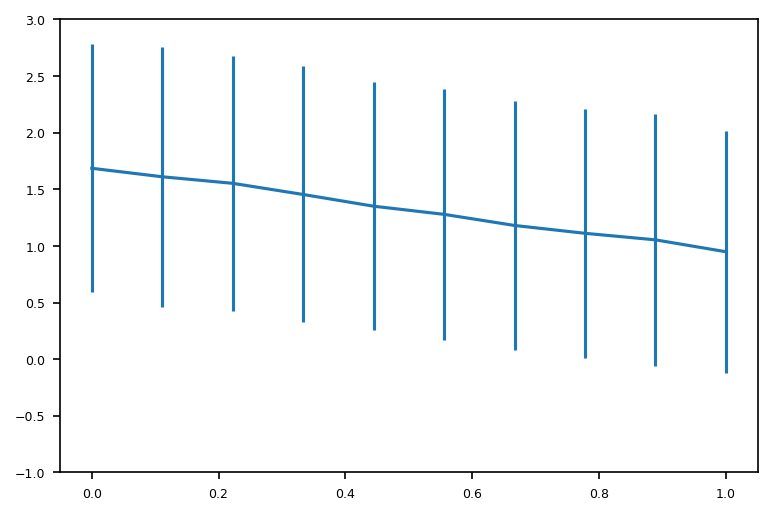

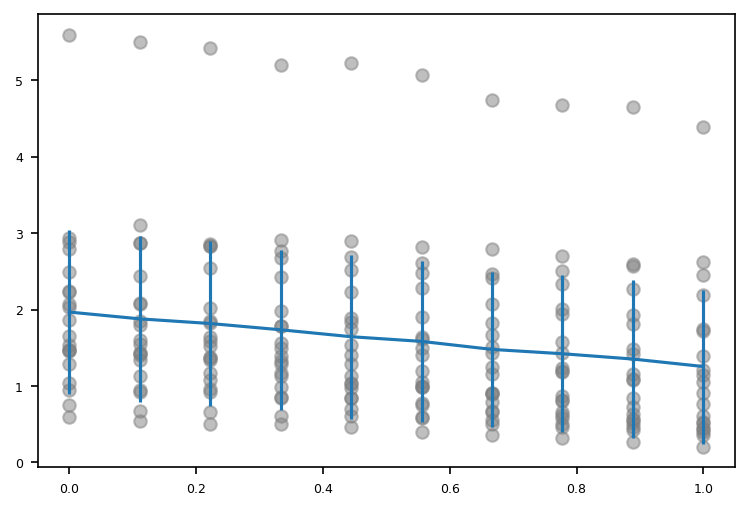

In [54]:
plt.figure()
plt.errorbar(teacher_speeds, training_loss_all_tasks.mean(1)[:, 0, -1], training_loss_all_tasks.std(1)[:, 0, -1])
plt.ylim(-1, 3)

plt.figure()
plt.errorbar(teacher_speeds, test_loss_all_tasks.mean(1)[:, 0, -1], test_loss_all_tasks.std(1)[:, 0, -1])
for seed in range(NUM_SEEDS):
    plt.scatter(teacher_speeds, test_loss_all_tasks[:, seed, 0, -1], color='gray', alpha=0.5)
# plt.ylim(-1, 3)
# for seed in range(NUM_SEEDS):
#     plt.plot(teacher_speeds, training_loss_all_tasks[:, seed, -1], color='gray', alpha=0.5)

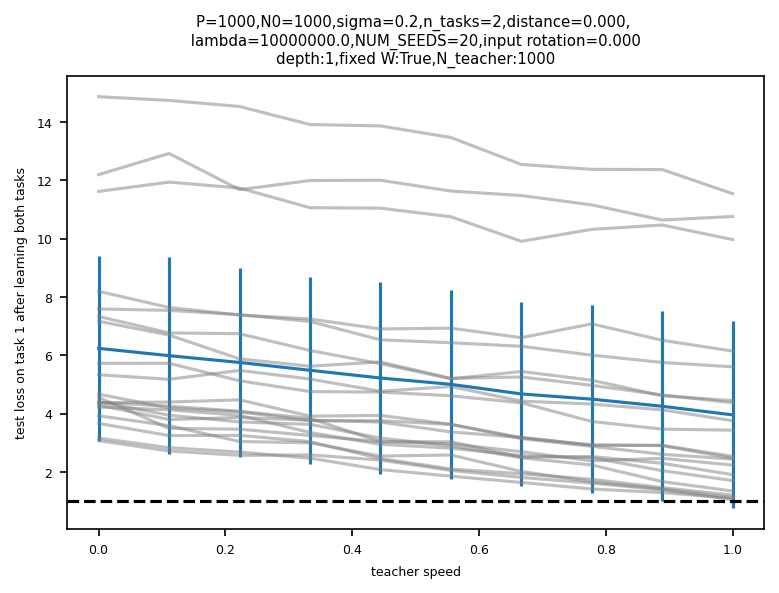

In [47]:
normalized_test_loss_on_first_task = test_loss_all_tasks[:, :, 0, :] / test_loss_all_tasks[:, :, 0, 0][:, :, None]

plt.figure()
plt.errorbar(teacher_speeds, normalized_test_loss_on_first_task.mean(1)[:, -1], normalized_test_loss_on_first_task.std(1)[:, -1])
for seed in range(NUM_SEEDS):
    plt.plot(teacher_speeds, normalized_test_loss_on_first_task[:, seed, -1], color='gray', alpha=0.5)
# plt.axhline(test_loss_all_tasks.mean(1)[0, 0, 0])

plt.title(title_text)

# plt.yscale('log')
plt.xlabel('teacher speed')
plt.ylabel('test loss on task 1 after learning both tasks')
# plt.ylim(0, 3)
plt.axhline(1, color='k', ls='--')

In [19]:
train_Y[].mean()

tensor(-0.2669)

In [49]:
theory.arccos_kernel_deep(train_x[0], train_x[1], 1, depth=1)

/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:335: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  


NameError: name 'torch' is not defined

In [29]:
import time
now = time.time()
np.linalg.inv(np.random.normal(np.zeros((1000, 1000), dtype=np.float32)))
print(time.time() - now)

0.07026004791259766


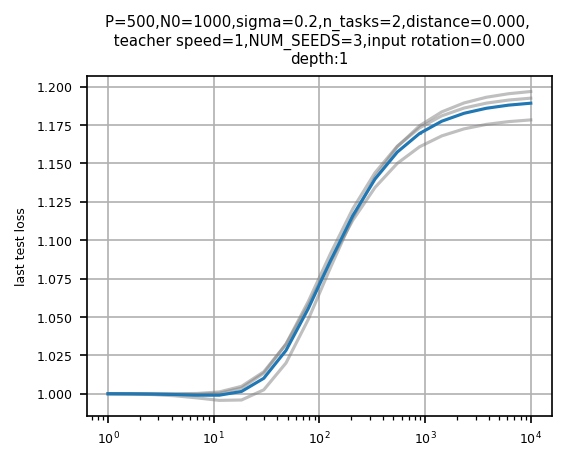

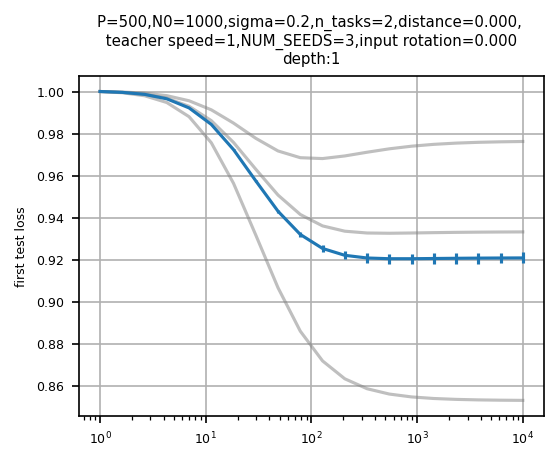

In [9]:
task_weights = np.ones(n_tasks) / n_tasks

def plot_data(data_mat, adjust, task):
    plt.figure(figsize=(4, 3))
    plt.xscale('log')

    plt.grid()
    plt.title(title_text)
    # assume a shape of sweed_ind x seed_ind x task_ind
    data_mat = data_mat.copy()
    if adjust:
        data_mat /= data_mat[0]
    assert task in ['mean', 'last', 'first']
    if task == 'mean':
        task_weights = np.ones(n_tasks) / n_tasks
    elif task == 'last':
        task_weights = np.zeros(n_tasks)
        task_weights[-1] = 1
    elif task == 'first':
        task_weights = np.zeros(n_tasks)
        task_weights[0] = 1
    plt.errorbar(lamb_values, data_mat.mean(1) @ task_weights, data_mat.var(1) @ task_weights)
    # plt.errorbar(lamb_values, data_mat.mean(1)[:< -1], data_mat.var(1).mean(-1))
    for seed in range(data_mat.shape[1]):
        plt.plot(lamb_values, data_mat[:, seed, :] @ task_weights, color='gray', alpha=0.5)
    plt.ylabel(task + ' test loss')


plot_data(test_loss_all_tasks, True, 'last')
plot_data(test_loss_all_tasks, True, 'first')


In [6]:
training_variances, test_variances, =\
    theory.compute_predictor_variances(seq_of_train_x=train_x,
                                       w_var=sigma**2, P_test=P_test,
                                       lambda_val=1,
                                       seq_of_test_x=test_x,
                                       fix_weights=fixed_w, depth=depth)

In [10]:
test_variances.max()

0.0005414465270550124

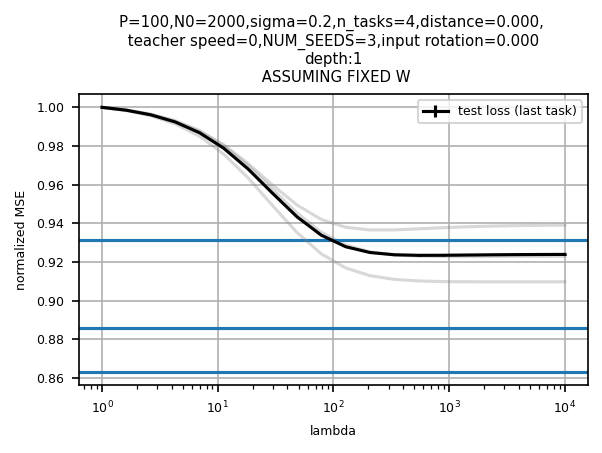

In [40]:

# plt.axhline(seed_avg_last_task_only_test, color='b', label='only learn last task')
# plt.axhline(seed_avg_batch_test, color='r', label='batch')
# plt.axhline(0, color='r', label='batch')
plt.errorbar(lamb_values, adjusted_test_loss[:, :, -1].mean(1), adjusted_test_loss[:, :, -1].var(1), color='k', label='test loss (last task)')

for i in range(NUM_SEEDS):
    plt.plot(lamb_values, adjusted_test_loss[:, i, -1], color='gray', alpha=0.3)
    plt.axhline(adjusted_batch_test[i])

plt.ylabel('normalized MSE')

plt.xlabel('lambda')
plt.xscale('log')
plt.grid()
plt.legend()

plt.title(title_text)
plt.tight_layout()
plt.show()

# colors = np.linspace(0, 1, len(lamb_values))
# task_to_look_at = 1
# plt.figure(figsize=(4, 3))
# for i in range(len(lamb_values)):
#     plt.plot(training_loss_all_tasks[i, 2, task_to_look_at:, task_to_look_at], color=str(colors[i]))

NameError: name 'student_type' is not defined

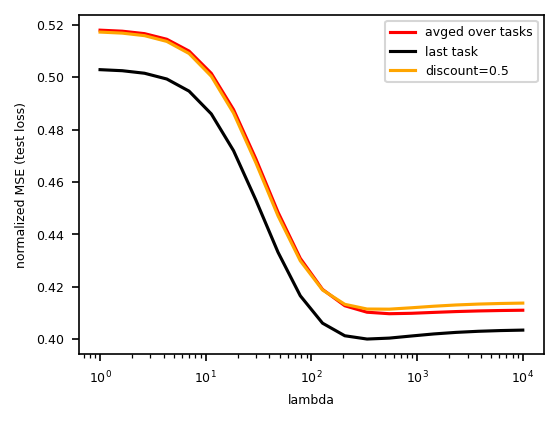

In [5]:
mean_test_loss_all_tasks = test_loss_all_tasks.mean(1)
mean_train_loss_all_tasks = training_loss_all_tasks.mean(1)

discount_factor = 0.5
exponential_scale = discount_factor ** np.arange(n_tasks)[::-1]
exponential_scale /= exponential_scale.sum()

plt.figure(figsize=(4, 3))
# plt.axhline(seed_avg_last_task_only_test, color='b', label='only learn last task')
# plt.axhline(seed_avg_batch_test, color='r', label='batch')
# plt.axhline(0, color='r', label='batch')
plt.plot(lamb_values, mean_test_loss_all_tasks.mean(1), color='r', label='avged over tasks')
plt.plot(lamb_values, mean_test_loss_all_tasks[:, -1], color='k', label='last task')
plt.plot(lamb_values, (mean_test_loss_all_tasks * exponential_scale).sum(-1), color='orange', label=f'discount={discount_factor}')
plt.ylabel('normalized MSE (test loss)')
plt.xscale('log')
plt.legend()
plt.xlabel('lambda')
title_text = f'P={P},N0={N0},sigma={sigma},n_tasks={n_tasks},distance={input_dist:.3f}, \n ' +\
          f'teacher speed={teacher_speed},NUM_SEEDS={NUM_SEEDS},input rotation={input_rotation:.3f} \n' +\
    f'network:{student_type}'
if fixed_w:
    title_text += '\n ASSUMING FIXED W'
plt.title(title_text)

Text(0.5, 1.0, 'colors: cool->warm: first->last task')

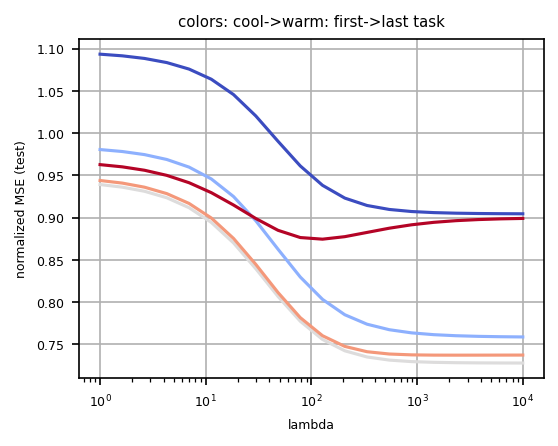

In [36]:
plt.figure(figsize=(4, 3))
colors = plt.cm.coolwarm(np.linspace(0, 1, n_tasks))
for task_ind in range(n_tasks):
    plt.plot(lamb_values, mean_test_loss_all_tasks[:, task_ind], color=colors[task_ind])
plt.xscale('log')
plt.xlabel('lambda'); plt.ylabel('normalized MSE (test)'); plt.grid()
plt.title('colors: cool->warm: first->last task')

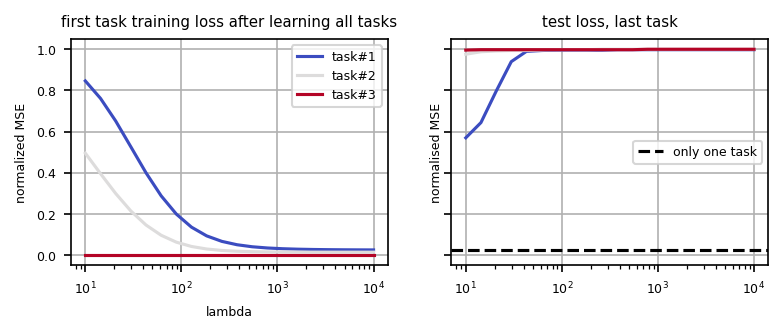

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2), sharey=True)
colors = plt.cm.coolwarm(np.linspace(0, 1, n_tasks))
axes = axes.ravel()
plt.sca(axes[0])
for i in range(n_tasks):
    plt.plot(lamb_values, mean_train_loss_all_tasks[:, -1, i], label=f'task#{i+1}', color=colors[i])
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('normalized MSE')
plt.title('first task training loss after learning all tasks')
plt.grid()
plt.legend()



plt.sca(axes[1])
for i in range(n_tasks):fd
    plt.plot(lamb_values, mean_test_loss_all_tasks[:, i], color=colors[i])
plt.axhline(seed_avg_last_task_only_test, color='k', ls='--', label='only one task')
plt.xscale('log')
plt.grid()
plt.ylabel('normalised MSE')
plt.title('test loss, last task')
plt.legend()

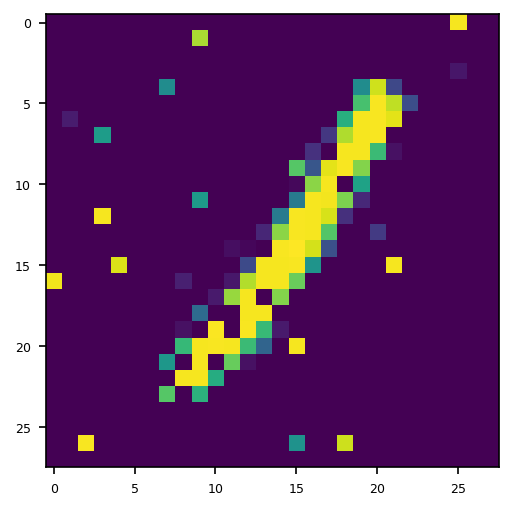

In [13]:
plt.figure()
plt.imshow(train_x[2][0].reshape(28, 28))